In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/raw/train.csv.zip")

In [3]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [5]:
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

In [6]:
df[labels].describe(percentiles = [0, 0.5, 1])

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
100%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


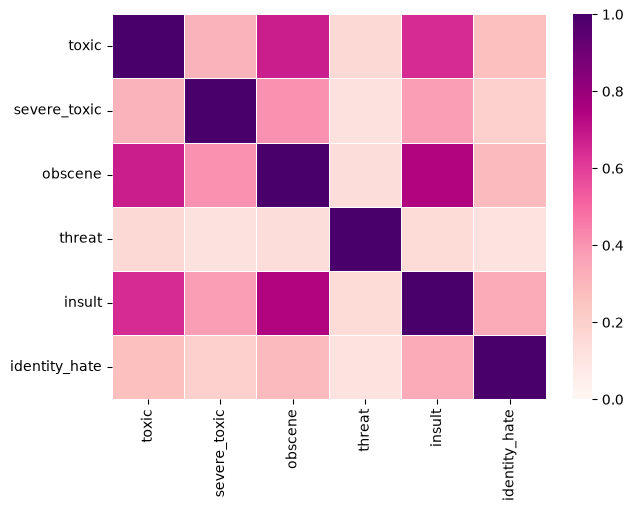

In [7]:
fig, ax = plt.subplots(figsize = (7, 5))

corr_matrix = df[labels].corr()

sns.heatmap(
    corr_matrix,
    linewidth = 0.5,
    cmap = "RdPu",
    vmin = 0,
    vmax = 1,
    ax = ax
);

In [19]:
def generate_wc(series, axes = None):
    
    text = " ".join(series)
    wc = WordCloud().generate(text)

    if axes == None:
        plt.imshow(wc, interpolation = 'bilinear')
        plt.axis('off')
    else :
        axes.imshow(wc, interpolation = 'bilinear')
        axes.axis('off')

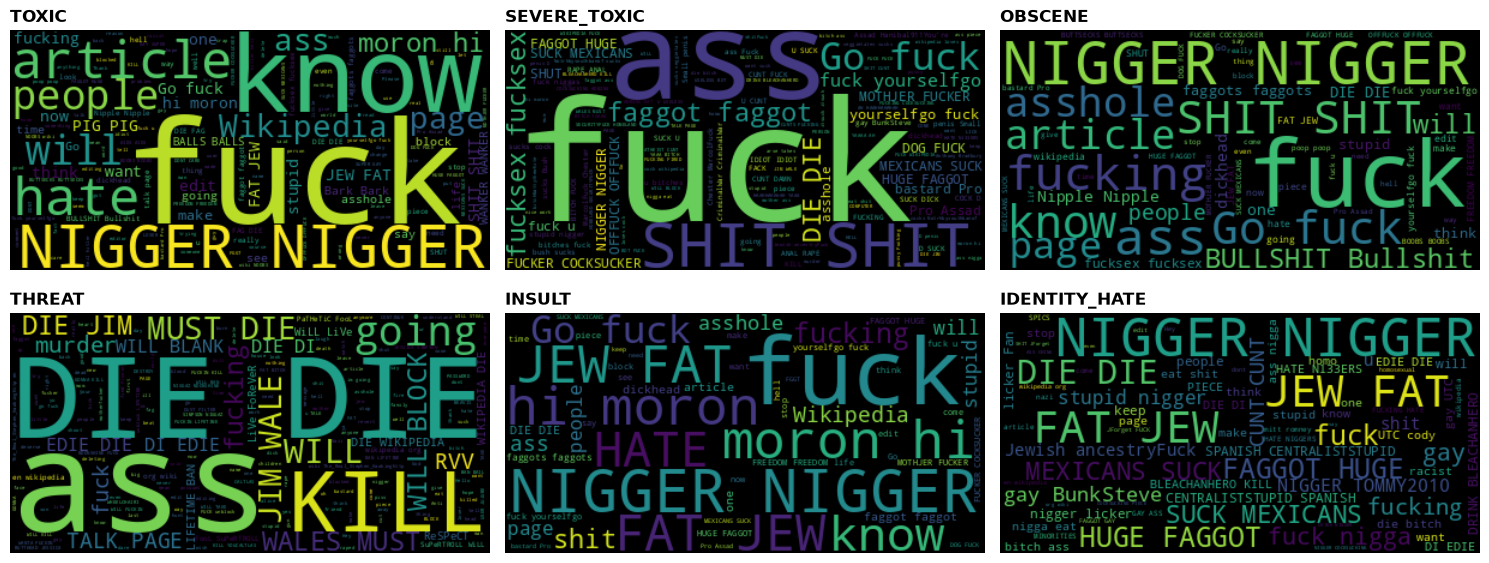

In [27]:
fig, axes = plt.subplots(ncols = 3, nrows = 2, figsize = (15, 6))
axes = axes.flatten()

for i, label in enumerate(labels):
    cond = df[label] == 1
    req_df = df.loc[cond, 'comment_text']
    generate_wc(req_df, axes[i])
    axes[i].set_title(label.upper(), loc = 'left', fontweight = 'bold')

plt.tight_layout()

In [29]:
df[df.duplicated()]['comment_text']

Series([], Name: comment_text, dtype: object)

In [31]:
def text_normalize(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

In [33]:
text = df['comment_text'].apply(text_normalize)

In [42]:
dup = text.duplicated()
text[dup].shape

(710,)